In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('student_clustering.csv')
print(f'the shape of the dataset is {df.shape}')
print(df.head())

the shape of the dataset is (200, 2)
   cgpa   iq
0  5.13   88
1  5.90  113
2  8.36   93
3  8.27   97
4  5.45  110


Text(0, 0.5, 'IQ')

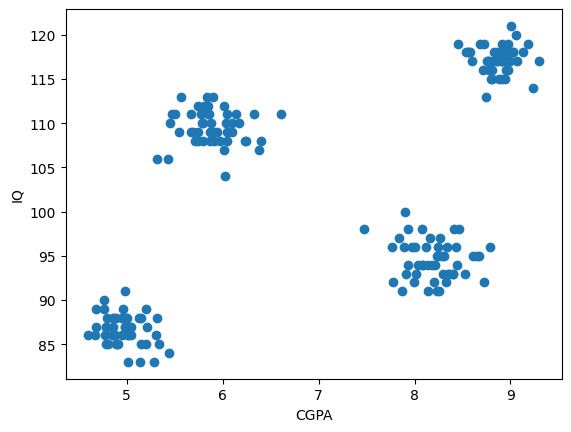

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df['cgpa'],df['iq'])
plt.xlabel('CGPA')
plt.ylabel('IQ')

In [ ]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init='k-means++',random_state=42)
    #k-means++ is a method for initializing the centroids in the K-means algorithm. It helps to improve the convergence and performance of the algorithm by selecting initial centroids that are more likely to lead to better clustering results.
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)
print(wcss)

In [13]:
wcss

[29957.898288,
 4184.14127,
 2364.005583420083,
 681.9696599999999,
 514.1616803171114,
 437.4804922280702,
 312.17121459855684,
 242.41587382556415,
 219.5382138115585,
 184.0059919717317]

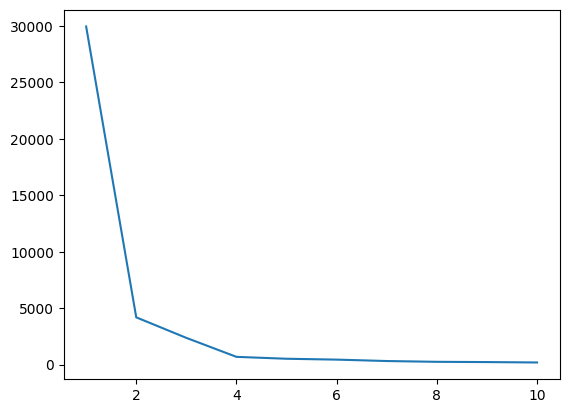

In [14]:
plt.plot(range(1,11),wcss)

In [15]:
x = df.iloc[:,:].values
#this is done because the KMeans algorithm expects the input data to be in the form of a 2D array, where each row represents a data point and each column represents a feature. By using .iloc[:,:].values, we are selecting all rows and all columns of the DataFrame and converting it into a NumPy array, which is the expected format for the KMeans algorithm.

kn = KMeans(n_clusters=4,init='k-means++',random_state=42)
y_mean = kn.fit_predict(x)

In [16]:
y_mean

array([1, 0, 2, 2, 0, 0, 2, 3, 0, 2, 1, 0, 2, 1, 0, 2, 0, 2, 0, 0, 2, 1,
       2, 1, 1, 2, 1, 3, 2, 0, 3, 0, 3, 0, 2, 2, 3, 0, 1, 0, 1, 2, 2, 1,
       3, 3, 2, 0, 3, 0, 1, 1, 3, 2, 3, 0, 0, 3, 0, 3, 0, 2, 2, 3, 1, 3,
       2, 1, 0, 2, 0, 3, 2, 1, 0, 3, 0, 3, 1, 2, 2, 3, 0, 1, 3, 1, 3, 0,
       3, 0, 3, 3, 2, 1, 2, 2, 3, 2, 1, 3, 0, 1, 1, 3, 1, 1, 2, 1, 3, 3,
       2, 3, 0, 0, 2, 3, 2, 0, 3, 1, 1, 0, 2, 3, 2, 1, 2, 0, 1, 2, 2, 0,
       1, 1, 0, 3, 0, 1, 2, 2, 2, 1, 0, 1, 1, 3, 1, 3, 0, 1, 3, 1, 3, 3,
       1, 2, 0, 3, 0, 2, 1, 3, 0, 2, 3, 1, 0, 1, 1, 3, 3, 0, 3, 1, 1, 2,
       3, 0, 1, 3, 3, 0, 0, 0, 2, 1, 2, 2, 3, 0, 2, 2, 1, 1, 2, 1, 3, 0,
       0, 3], dtype=int32)

In [17]:
x[y_mean == 0,0],x[y_mean == 0,1]

(array([5.9 , 5.45, 5.88, 5.79, 6.1 , 5.71, 5.5 , 6.05, 5.84, 5.43, 6.01,
        5.32, 5.91, 5.57, 6.4 , 5.67, 6.05, 5.85, 5.87, 6.02, 5.77, 6.06,
        5.55, 5.81, 5.47, 5.74, 5.8 , 5.88, 5.91, 5.67, 5.74, 5.69, 6.05,
        6.14, 5.74, 5.94, 5.86, 6.38, 6.61, 6.04, 6.24, 6.1 , 5.8 , 5.87,
        5.97, 6.17, 6.01, 6.33, 5.85, 6.23]),
 array([113., 110., 109., 110., 110., 108., 111., 111., 113., 106., 112.,
        106., 108., 113., 108., 109., 108., 111., 109., 104., 111., 109.,
        109., 112., 111., 109., 108., 110., 109., 111., 108., 109., 109.,
        111., 112., 109., 111., 107., 111., 110., 108., 109., 110., 108.,
        108., 110., 107., 111., 112., 108.]))

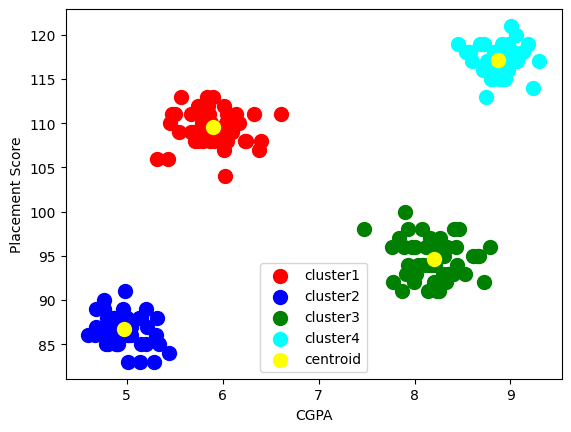

In [18]:
plt.scatter(x[y_mean == 0,0],x[y_mean == 0,1],s=100,c='red',label='cluster1')

plt.scatter(x[y_mean == 1,0],x[y_mean == 1,1],s=100,c='blue',label='cluster2')

plt.scatter(x[y_mean == 2,0],x[y_mean == 2,1
],s=100,c='green',label='cluster3')

plt.scatter(x[y_mean == 3,0],x[y_mean == 3,1],s=100,c='cyan',label='cluster4')

plt.scatter(kn.cluster_centers_[:,0],kn.cluster_centers_[:,1],s=100,c='yellow',label='centroid')

plt.xlabel('CGPA')
plt.ylabel('Placement Score')

plt.legend()
plt.show()

In [19]:
"""K-means on a 3-D data"""

from sklearn.datasets import make_blobs

centroids = [(-5,-5,5),(5,5,-5),(3.5,-2.5,4),(-2.5,2.5,-4)]
cluster_std = [1,1,1,1]

X, y = make_blobs(n_samples=1000, centers=centroids, cluster_std=cluster_std, random_state=42,n_features=3)

In [20]:
X

array([[-4.41225498,  2.43136595, -5.36831504],
       [ 5.56252492, -3.56753291,  4.02421946],
       [-5.28865864, -4.67728144,  4.17276906],
       ...,
       [-3.73252331,  3.05229994, -3.37436907],
       [ 2.136826  , -2.31029383,  3.33801782],
       [ 5.8177663 ,  6.39020755, -4.44218969]], shape=(1000, 3))

In [21]:
import plotly.express as px
fig = px.scatter_3d(x=X[:,0],y=X[:,1],z=X[:,2],color=y)
fig.show()

In [22]:
wcss1 = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(X)
    wcss1.append(kmeans.inertia_)


In [23]:
wcss1

[56551.89930766376,
 21309.258389762585,
 11299.259762546273,
 2902.1725984642003,
 2747.3240380185816,
 2575.524164666549,
 2386.759839571468,
 2187.131673669406,
 2082.7241438571887,
 1990.1505648878208]

Text(0.5, 1.0, 'The Elbow Method')

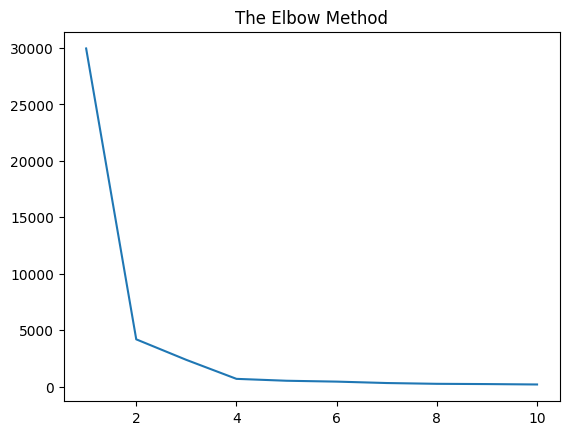

In [24]:
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')

In [25]:
km = KMeans(n_clusters=4,init='k-means++',random_state=42)
y_means = km.fit_predict(X)

In [26]:
df = pd.DataFrame()

df['col1'] = X[:,0]
df['col2'] = X[:,1]
df['col3'] = X[:,2]
df['label'] = y_means

In [27]:
fig = px.scatter_3d(df,x='col1',y='col2',z='col3',color='label')
fig.show()